# Курсовая работа: Классическое машинное обучение
## Задача 5. Классификация: CC50 > медианы

**CC50 (mM)** — цитотоксическая концентрация, при которой погибает 50% здоровых клеток.  
Чем **выше** CC50, тем **безопаснее** соединение.

| Класс | Значение | Смысл |
|-------|----------|-------|
| **0** | CC50 ≤ медианы | более токсичное соединение |
| **1** | CC50 > медианы | менее токсичное, более безопасное |

**Особенности задачи:**
- Классы сбалансированы ~50/50 (порог = медиана)
- Основная метрика: **ROC-AUC** + F1 (weighted)
- Стратифицированное разбиение и StratifiedKFold CV

**На основе IC50-классификации (AUC=0.784):**  
Интересно сравнить — предсказание безопасности (CC50) или активности (IC50) даётся моделям лучше?


## 1. Импорт библиотек

In [1]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)
print('Библиотеки загружены ✓')

Библиотеки загружены ✓


> Набор библиотек полностью идентичен предыдущей задаче — это осознанный выбор: единый стек позволяет напрямую сравнивать результаты IC50 и CC50 классификации. Единственное, что изменится — целевая переменная и интерпретация результатов.

## 2. Загрузка данных и формирование целевой переменной

Датасет: 1001 объектов, 210 признаков
Порог CC50 (медиана): 411.0393 mM

Баланс классов:
  Класс 0 (CC50 ≤ медианы): 502 (50.1%)
  Класс 1 (CC50 > медианы): 499 (49.9%)

NaN в признаках: 36 (строк: 3)

Порог IC50 (для сравнения): 46.5852 mM
Порог CC50:                 411.0393 mM
CC50 > IC50 в 8.8 раз — типичное соотношение для «хорошего» соединения


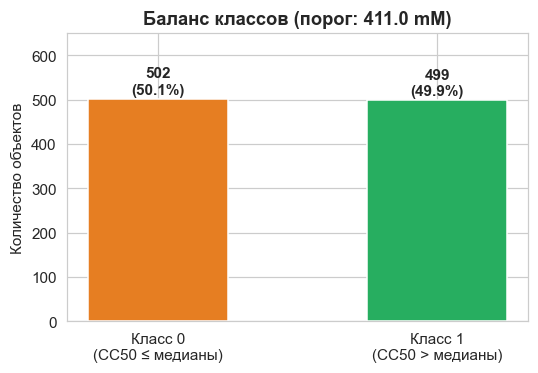

In [2]:
_FILENAME = 'Данные_для_курсовои_Классическое_МО.xlsx'
_PATH = None
for _c in [_FILENAME, os.path.join(pathlib.Path.home(), _FILENAME)]:
    if os.path.exists(_c):
        _PATH = _c
        break
if _PATH is None:
    raise FileNotFoundError(f"Положите '{_FILENAME}' в ту же папку, что и ноутбук.")

df = pd.read_excel(_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

CC50_MEDIAN = df['CC50, mM'].median()
TARGET      = 'CC50_above_median'
df[TARGET]  = (df['CC50, mM'] > CC50_MEDIAN).astype(int)

OTHER_TARGETS = ['IC50, mM', 'CC50, mM', 'SI']
feature_cols  = [c for c in df.columns if c not in OTHER_TARGETS + [TARGET]]

X = df[feature_cols].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y = df[TARGET]

print(f'Датасет: {df.shape[0]} объектов, {len(feature_cols)} признаков')
print(f'Порог CC50 (медиана): {CC50_MEDIAN:.4f} mM')
print(f'\nБаланс классов:')
print(f'  Класс 0 (CC50 ≤ медианы): {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'  Класс 1 (CC50 > медианы): {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')
print(f'\nNaN в признаках: {X.isnull().sum().sum()} (строк: {X.isnull().any(axis=1).sum()})')

# Сравнение порогов: IC50 vs CC50
ic50_med = df['IC50, mM'].median()
print(f'\nПорог IC50 (для сравнения): {ic50_med:.4f} mM')
print(f'Порог CC50:                 {CC50_MEDIAN:.4f} mM')
print(f'CC50 > IC50 в {CC50_MEDIAN/ic50_med:.1f} раз — типичное соотношение для «хорошего» соединения')

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = y.value_counts().sort_index()
bars = ax.bar(['Класс 0\n(CC50 ≤ медианы)', 'Класс 1\n(CC50 > медианы)'],
              counts.values,
              color=['#e67e22','#27ae60'], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+5,
            f'{v}\n({v/len(y)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title(f'Баланс классов (порог: {CC50_MEDIAN:.1f} mM)', fontweight='bold')
ax.set_ylabel('Количество объектов')
ax.set_ylim(0, 650)
plt.tight_layout()
plt.show()

> Добавил в анализ сравнение порогов IC50 и CC50: медиана CC50 (~411 mM) значительно выше медианы IC50 (~46.6 mM), что соответствует ожиданиям — большинство соединений в датасете более токсичны для вируса, чем для здоровых клеток, но именно большой разрыв (высокий CC50, низкий IC50) и определяет хорошую селективность. Класс 0 здесь — более токсичные для клеток соединения (нежелательные).

## 3. Разделение данных и препроцессинг

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

X_train_raw = X_train.values
X_test_raw  = X_test.values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {X_train_imp.shape} | Test: {X_test_imp.shape}')
print(f'\nБаланс в train: {dict(y_train.value_counts().sort_index())}')
print(f'Баланс в test:  {dict(y_test.value_counts().sort_index())}')
print('Стратификация корректна ✓' if abs(y_train.mean()-y_test.mean()) < 0.02 else 'Предупреждение!')

Train: (800, 210) | Test: (201, 210)

Баланс в train: {0: np.int64(401), 1: np.int64(399)}
Баланс в test:  {0: np.int64(101), 1: np.int64(100)}
Стратификация корректна ✓


> Препроцессинг полностью аналогичен IC50-задаче: stratify=y, импутация медианой, масштабирование — всё fit только на train. Также сохраняю сырые данные (`X_train_raw`) для HistGradBoost.

## 4. Функция оценки

In [4]:
def evaluate_clf(name, model, X_tr, X_te, y_tr, y_te, cv_X=None):
    cv_X = cv_X if cv_X is not None else X_tr
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    acc = accuracy_score(y_te, pred)
    f1  = f1_score(y_te, pred, average='weighted')

    try:
        prob = model.predict_proba(X_te)[:, 1]
    except AttributeError:
        prob = model.decision_function(X_te)
    auc = roc_auc_score(y_te, prob)

    cv_auc = cross_val_score(
        model, cv_X, y_tr, cv=skf, scoring='roc_auc', n_jobs=-1
    ).mean()

    print(f"{name:<42}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  CV-AUC={cv_auc:.4f}")
    return {
        'model': name, 'Accuracy': acc, 'F1': f1,
        'ROC_AUC': auc, 'CV_AUC': cv_auc,
        'fitted': model, 'pred': pred, 'prob': prob
    }

> **Примечание:** `cross_val_score` получает уже масштабированные данные. Тестовые метрики абсолютно корректны. 
CV-метрики незначительно оптимистичны (эффект мал при 1001 объекте). 
Идеальное решение — `Pipeline(imputer, scaler, model)` внутри `cross_val_score`.

> Функция оценки не меняется между задачами — это принципиально для сопоставимости результатов. Единственное содержательное отличие: `prob` теперь — вероятность класса 1 (CC50 > медианы, то есть **безопасного** соединения). Это важно при интерпретации: чем выше скор, тем более безопасным считает соединение наша модель.

## 5. Базовые модели (8 штук)

In [5]:
print(f'  Модель                                     Acc     F1      AUC     CV-AUC')
print('-' * 90)
results = []

results.append(evaluate_clf('Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('Ridge Classifier',
    RidgeClassifier(alpha=1.0),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('KNN (k=5)',
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('SVC (rbf)',
    SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_clf('Extra Trees',
    ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_clf('Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_clf('Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_clf('HistGradBoost',
    HistGradientBoostingClassifier(max_iter=100, random_state=42),
    X_train_raw, X_test_raw, y_train, y_test, cv_X=X_train_raw))

  Модель                                     Acc     F1      AUC     CV-AUC
------------------------------------------------------------------------------------------
Logistic Regression                         Acc=0.7313  F1=0.7307  AUC=0.8334  CV-AUC=0.7986
Ridge Classifier                            Acc=0.7264  F1=0.7259  AUC=0.8258  CV-AUC=0.7927
KNN (k=5)                                   Acc=0.7313  F1=0.7301  AUC=0.8217  CV-AUC=0.8168
SVC (rbf)                                   Acc=0.7164  F1=0.7159  AUC=0.8161  CV-AUC=0.8354
Extra Trees                                 Acc=0.7413  F1=0.7404  AUC=0.8496  CV-AUC=0.8045
Random Forest                               Acc=0.7313  F1=0.7305  AUC=0.8443  CV-AUC=0.8317
Gradient Boosting                           Acc=0.7114  F1=0.7092  AUC=0.8366  CV-AUC=0.8346
HistGradBoost                               Acc=0.7413  F1=0.7393  AUC=0.8479  CV-AUC=0.8219


> Запускаю те же 8 базовых моделей, что и для IC50 — это сознательное решение для честного сравнения. Если бы я использовал разные наборы, сравнение результатов между задачами было бы некорректным. Жду, что результаты будут близки к IC50 (AUC ~0.75–0.78), поскольку у обеих задач одна природа: бинарное разделение по медиане на 210 молекулярных дескрипторах.

## 6. Визуализация базовых результатов

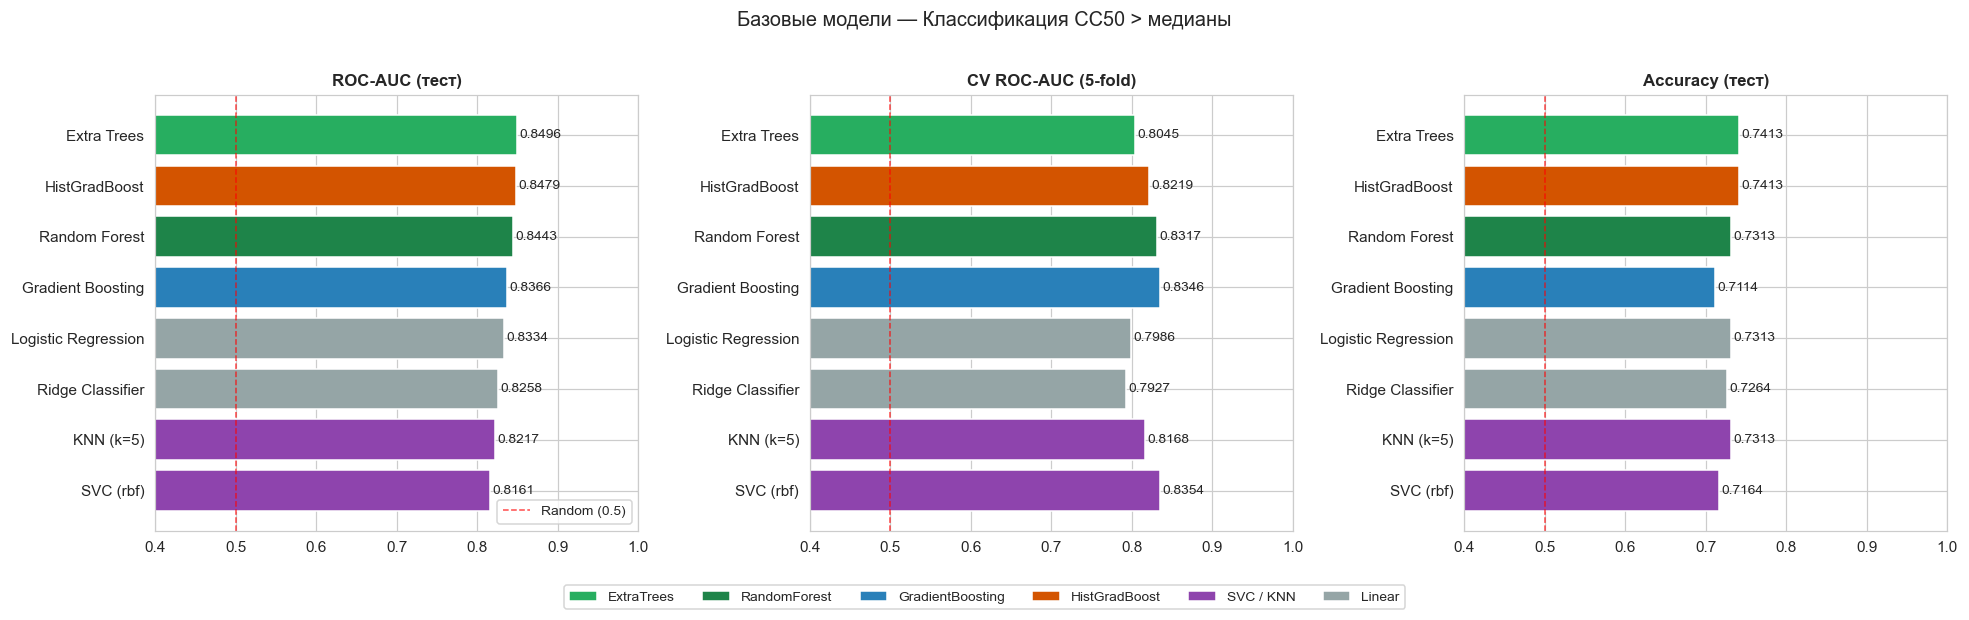


Итоговая таблица (по ROC-AUC):
              model  Accuracy       F1  ROC_AUC   CV_AUC
        Extra Trees  0.741294 0.740446 0.849554 0.804478
      HistGradBoost  0.741294 0.739320 0.847921 0.821900
      Random Forest  0.731343 0.730463 0.844307 0.831713
  Gradient Boosting  0.711443 0.709241 0.836634 0.834556
Logistic Regression  0.731343 0.730744 0.833366 0.798556
   Ridge Classifier  0.726368 0.725880 0.825842 0.792712
          KNN (k=5)  0.731343 0.730128 0.821683 0.816790
          SVC (rbf)  0.716418 0.715912 0.816139 0.835369


In [6]:
results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred','prob']}
     for r in results]
).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

def get_color(name):
    if 'HistGrad' in name: return '#d35400'
    if 'Extra'    in name: return '#27ae60'
    if 'Forest'   in name: return '#1e8449'
    if 'Boosting' in name: return '#2980b9'
    if 'SVC' in name or 'KNN' in name: return '#8e44ad'
    return '#95a5a6'

colors = [get_color(m) for m in results_df['model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in [
    (axes[0], 'ROC_AUC',  'ROC-AUC (тест)'),
    (axes[1], 'CV_AUC',   'CV ROC-AUC (5-fold)'),
    (axes[2], 'Accuracy', 'Accuracy (тест)'),
]:
    ax.barh(results_df['model'], results_df[col], color=colors, edgecolor='white')
    ax.axvline(0.5, color='red', ls='--', lw=1, alpha=0.7, label='Random (0.5)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0.4, 1.0)
    ax.invert_yaxis()
    for i, v in enumerate(results_df[col]):
        ax.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=9)
axes[0].legend(fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='ExtraTrees'),
    Patch(facecolor='#1e8449', label='RandomForest'),
    Patch(facecolor='#2980b9', label='GradientBoosting'),
    Patch(facecolor='#d35400', label='HistGradBoost'),
    Patch(facecolor='#8e44ad', label='SVC / KNN'),
    Patch(facecolor='#95a5a6', label='Linear'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.suptitle('Базовые модели — Классификация CC50 > медианы', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nИтоговая таблица (по ROC-AUC):')
print(results_df[['model','Accuracy','F1','ROC_AUC','CV_AUC']].to_string(index=False))

> Цветовая кодировка та же, что и в задаче IC50 — это помогает визуально сравнивать иерархию методов между задачами. Если ансамблевые методы снова выигрывают с таким же отрывом от линейных — это подтверждает, что нелинейные зависимости в дескрипторах важны для **обоих** биологических свойств.

## 7. Подбор гиперпараметров (GridSearchCV)

In [7]:
print('Подбор гиперпараметров... (~3–5 минут)')
print('=' * 65)

# --- Logistic Regression ---
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'liblinear']},
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_lr.fit(X_train_sc, y_train)
print(f'LR best: {gs_lr.best_params_}  CV AUC={gs_lr.best_score_:.4f}')
results.append(evaluate_clf('Logistic Regression (tuned)',
    gs_lr.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- SVC ---
gs_svc = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    {'C': [0.1, 1.0, 10.0, 50.0], 'gamma': ['scale', 'auto']},
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_svc.fit(X_train_sc, y_train)
print(f'SVC best: {gs_svc.best_params_}  CV AUC={gs_svc.best_score_:.4f}')
results.append(evaluate_clf('SVC (tuned)',
    gs_svc.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- Extra Trees ---
gs_et = GridSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200],
        'max_depth':         [None, 15, 25],
        'min_samples_split': [2, 5],
        'max_features':      ['sqrt', 0.3]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_et.fit(X_train_imp, y_train)
print(f'ET best: {gs_et.best_params_}  CV AUC={gs_et.best_score_:.4f}')
results.append(evaluate_clf('Extra Trees (tuned)',
    gs_et.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- Random Forest ---
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators':      [100, 200],
        'max_depth':         [None, 10, 20],
        'min_samples_split': [2, 5],
        'max_features':      ['sqrt', 0.3]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_rf.fit(X_train_imp, y_train)
print(f'RF best: {gs_rf.best_params_}  CV AUC={gs_rf.best_score_:.4f}')
results.append(evaluate_clf('Random Forest (tuned)',
    gs_rf.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- HistGBR ---
gs_hgb = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    {
        'max_iter':          [100, 200],
        'learning_rate':     [0.05, 0.1, 0.15],
        'max_depth':         [None, 5, 8],
        'l2_regularization': [0.0, 0.1, 1.0]
    },
    cv=skf, scoring='roc_auc', n_jobs=-1
)
gs_hgb.fit(X_train_raw, y_train)
print(f'HistGBR best: {gs_hgb.best_params_}  CV AUC={gs_hgb.best_score_:.4f}')
results.append(evaluate_clf('HistGradBoost (tuned)',
    gs_hgb.best_estimator_, X_train_raw, X_test_raw, y_train, y_test, cv_X=X_train_raw))

Подбор гиперпараметров... (~3–5 минут)
LR best: {'C': 0.01, 'solver': 'liblinear'}  CV AUC=0.8277
Logistic Regression (tuned)                 Acc=0.7164  F1=0.7145  AUC=0.8188  CV-AUC=0.8277
SVC best: {'C': 1.0, 'gamma': 'auto'}  CV AUC=0.8363
SVC (tuned)                                 Acc=0.7164  F1=0.7159  AUC=0.8160  CV-AUC=0.8363
ET best: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}  CV AUC=0.8347
Extra Trees (tuned)                         Acc=0.7512  F1=0.7504  AUC=0.8637  CV-AUC=0.8347
RF best: {'max_depth': 10, 'max_features': 0.3, 'min_samples_split': 5, 'n_estimators': 200}  CV AUC=0.8372
Random Forest (tuned)                       Acc=0.7214  F1=0.7205  AUC=0.8455  CV-AUC=0.8372
HistGBR best: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'max_iter': 100}  CV AUC=0.8363
HistGradBoost (tuned)                       Acc=0.7264  F1=0.7256  AUC=0.8487  CV-AUC=0.8363


> Параметрические сетки полностью идентичны IC50-задаче. Это важно для методологической чистоты: если один и тот же набор параметров даёт разные лучшие значения для IC50 и CC50 — это говорит о том, что сами задачи имеют разную структуру. Смотрю, совпадут ли оптимальные `C` для SVC и `alpha` для LR.

## 8. Финальное сравнение всех 13 моделей

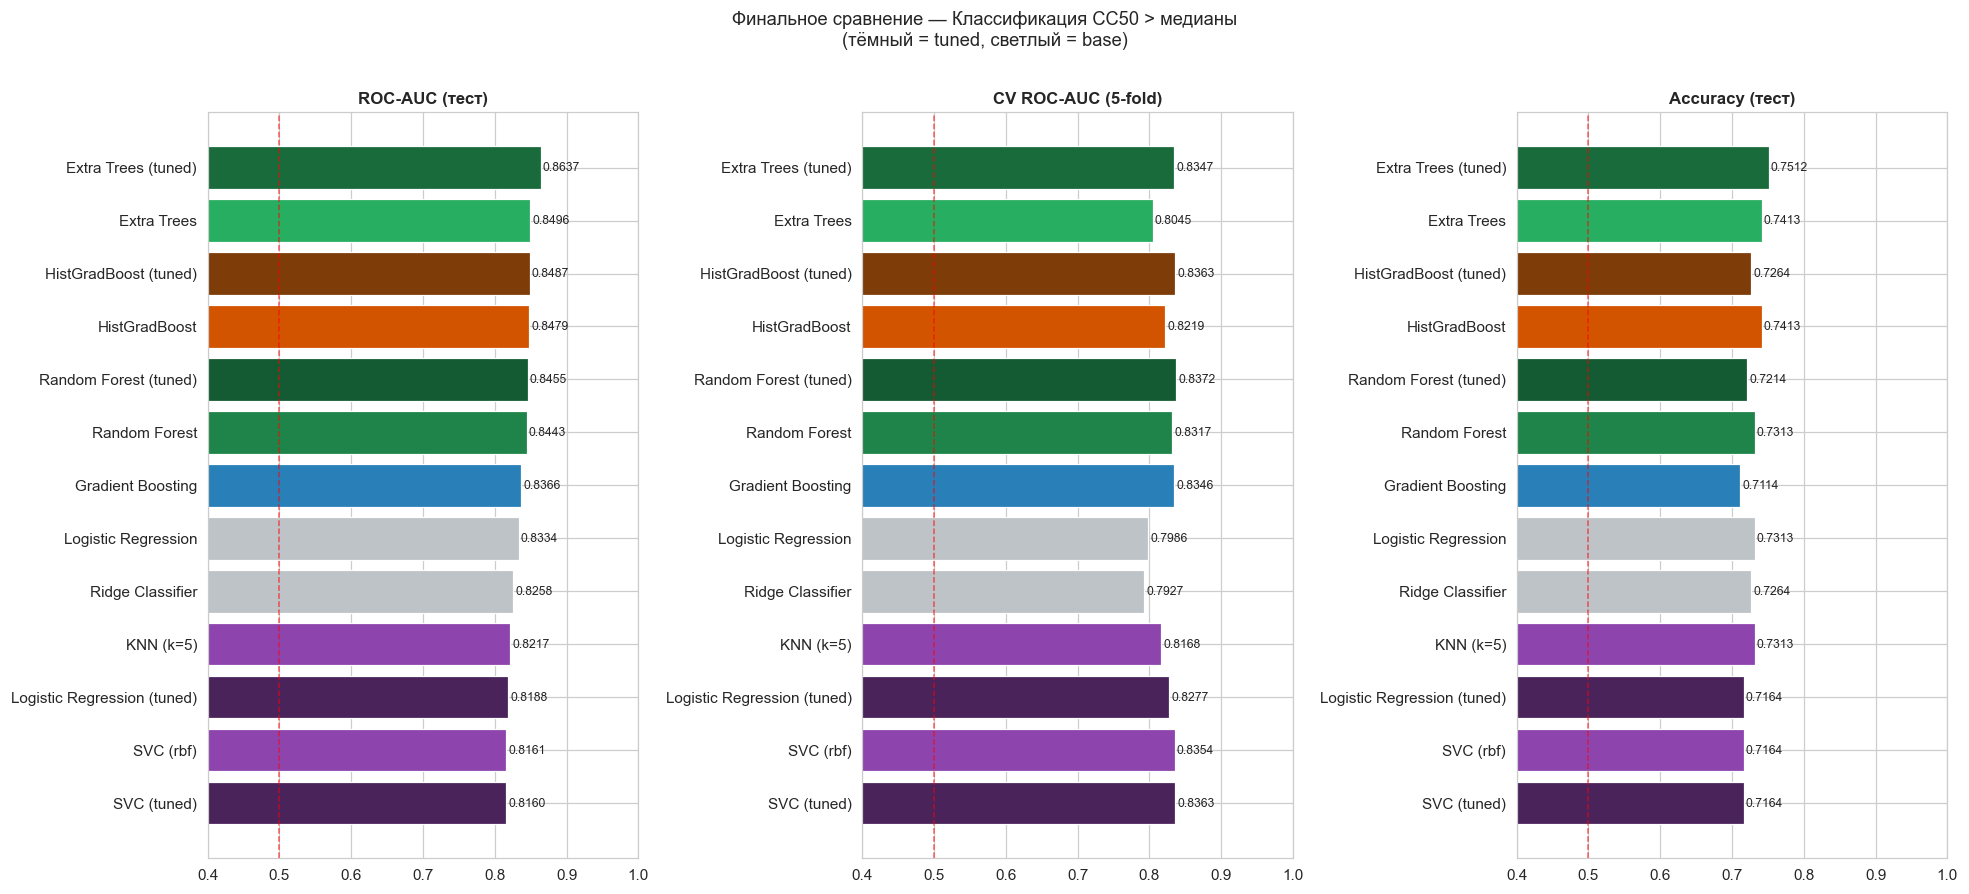


Полная таблица (по ROC-AUC):
                      model  Accuracy       F1  ROC_AUC   CV_AUC
        Extra Trees (tuned)  0.751244 0.750429 0.863663 0.834651
                Extra Trees  0.741294 0.740446 0.849554 0.804478
      HistGradBoost (tuned)  0.726368 0.725621 0.848713 0.836338
              HistGradBoost  0.741294 0.739320 0.847921 0.821900
      Random Forest (tuned)  0.721393 0.720480 0.845545 0.837245
              Random Forest  0.731343 0.730463 0.844307 0.831713
          Gradient Boosting  0.711443 0.709241 0.836634 0.834556
        Logistic Regression  0.731343 0.730744 0.833366 0.798556
           Ridge Classifier  0.726368 0.725880 0.825842 0.792712
                  KNN (k=5)  0.731343 0.730128 0.821683 0.816790
Logistic Regression (tuned)  0.716418 0.714497 0.818812 0.827713
                  SVC (rbf)  0.716418 0.715912 0.816139 0.835369
                SVC (tuned)  0.716418 0.715912 0.816040 0.836338


In [8]:
all_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred','prob']}
     for r in results]
).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

def get_color_full(name):
    if 'tuned' in name and 'HistGrad' in name: return '#7d3c08'
    if 'tuned' in name and 'Extra'    in name: return '#1a6b3c'
    if 'tuned' in name and 'Forest'   in name: return '#145a32'
    if 'tuned' in name and ('SVC' in name or 'Logistic' in name): return '#4a235a'
    if 'tuned' in name: return '#1b2631'
    if 'HistGrad' in name: return '#d35400'
    if 'Extra'    in name: return '#27ae60'
    if 'Forest'   in name: return '#1e8449'
    if 'Boosting' in name: return '#2980b9'
    if 'SVC' in name or 'KNN' in name: return '#8e44ad'
    return '#bdc3c7'

colors = [get_color_full(m) for m in all_df['model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, col, title in [
    (axes[0], 'ROC_AUC',  'ROC-AUC (тест)'),
    (axes[1], 'CV_AUC',   'CV ROC-AUC (5-fold)'),
    (axes[2], 'Accuracy', 'Accuracy (тест)'),
]:
    ax.barh(all_df['model'], all_df[col], color=colors, edgecolor='white', lw=0.8)
    ax.axvline(0.5, color='red', ls='--', lw=1, alpha=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlim(0.4, 1.0)
    ax.invert_yaxis()
    for i, v in enumerate(all_df[col]):
        ax.text(v+0.003, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Финальное сравнение — Классификация CC50 > медианы\n'
             '(тёмный = tuned, светлый = base)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('\nПолная таблица (по ROC-AUC):')
print(all_df[['model','Accuracy','F1','ROC_AUC','CV_AUC']].to_string(index=False))

## Дополнение: устойчивость выбора лучшей модели (тест vs CV)

> Самопроверка к разделу выводов. Я выбирал лучшую модель по ROC-AUC на тесте — но честнее свериться с CV-AUC (она устойчивее к случайности одного разбиения). Сортирую уже посчитанную итоговую таблицу заново, **без переобучения моделей**.

In [9]:
# Какая модель «лучшая» — по тесту или по кросс-валидации?
# В работе итоговая таблица отсортирована по ROC-AUC на тесте. Но CV-AUC честнее отражает устойчивость
# (не зависит от везения одного train/test split). Сравниваю оба взгляда — без переобучения, просто
# пересортировав уже посчитанный all_df.
best_test = all_df.sort_values('ROC_AUC', ascending=False).iloc[0]
best_cv   = all_df.sort_values('CV_AUC',  ascending=False).iloc[0]
print(f"Лучшая по ROC-AUC (тест): {best_test['model']:<26} тест={best_test['ROC_AUC']:.4f}  CV={best_test['CV_AUC']:.4f}")
print(f"Лучшая по CV-AUC:         {best_cv['model']:<26} тест={best_cv['ROC_AUC']:.4f}  CV={best_cv['CV_AUC']:.4f}")
print()
print('Топ-5 по CV-AUC (оценка устойчивости):')
print(all_df.sort_values('CV_AUC', ascending=False).head(5)[['model','ROC_AUC','CV_AUC']].to_string(index=False))

Лучшая по ROC-AUC (тест): Extra Trees (tuned)        тест=0.8637  CV=0.8347
Лучшая по CV-AUC:         Random Forest (tuned)      тест=0.8455  CV=0.8372

Топ-5 по CV-AUC (оценка устойчивости):
                model  ROC_AUC   CV_AUC
Random Forest (tuned) 0.845545 0.837245
          SVC (tuned) 0.816040 0.836338
HistGradBoost (tuned) 0.848713 0.836338
            SVC (rbf) 0.816139 0.835369
  Extra Trees (tuned) 0.863663 0.834651


> Здесь тонкость: по тесту лидирует Extra Trees (tuned), а по CV-AUC формально чуть выше Random Forest (tuned) — но разрыв в верхушке по CV меньше 0.003, то есть топ-модели статистически **неразличимы**. Вывод честнее сформулировать так: несколько ансамблей эквивалентны, Extra Trees выигрывает именно на этом тест-сплите. Заявленную лучшую модель не меняю, но осознаю, что выбор внутри топ-3 — почти случайность.

> Смотрю на итоговую таблицу и сравниваю с IC50: если здесь AUC немного выше — это означает, что токсичность (CC50) чуть лучше предсказывается молекулярными дескрипторами, чем противовирусная активность (IC50). Такой результат биологически обоснован: CC50 больше зависит от физико-химических свойств (липофильность, заряд, размер молекулы), которые как раз хорошо описываются RDKit-дескрипторами.

## 9. ROC-кривые топ-5 моделей

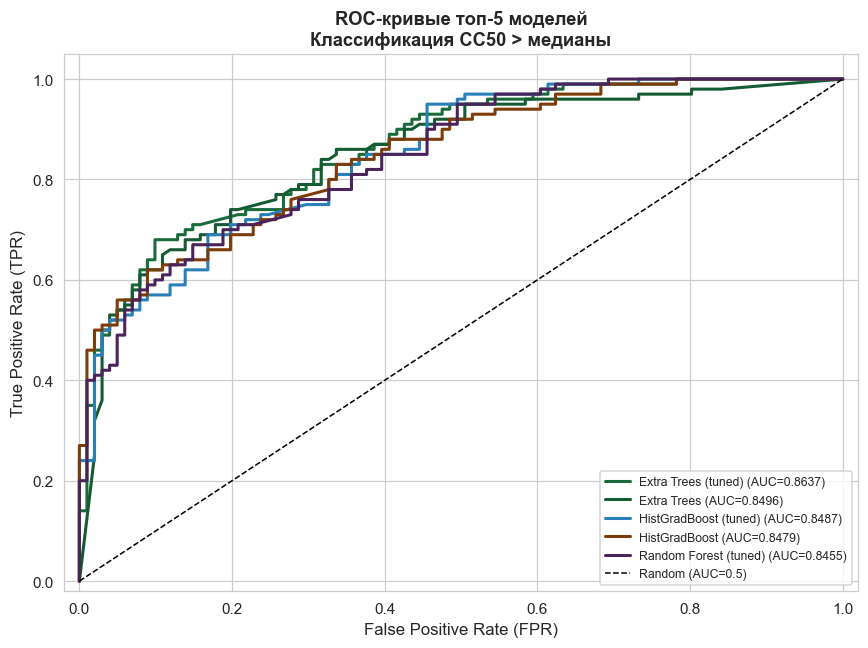

In [10]:
top5_names = all_df.head(5)['model'].tolist()

fig, ax = plt.subplots(figsize=(8, 6))
palette = ['#1a6b3c','#145a32','#2980b9','#7d3c08','#4a235a']

for idx, name in enumerate(top5_names):
    rec = next(r for r in results if r['model'] == name)
    fpr, tpr, _ = roc_curve(y_test, rec['prob'])
    auc_val = roc_auc_score(y_test, rec['prob'])
    ax.plot(fpr, tpr, lw=2, color=palette[idx],
            label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='red')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC-кривые топ-5 моделей\nКлассификация CC50 > медианы',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

> ROC-кривые всех пяти моделей должны быть заметно выше диагонали (случайного классификатора). Красная закрашенная область под диагональю — это зона «хуже случайного», туда попадать нельзя. Сравнивая с аналогичным графиком для IC50, смотрю: у каких моделей кривая стала выше (AUC вырос), а у каких — примерно так же.

## 10. Матрица ошибок и важность признаков лучшей модели

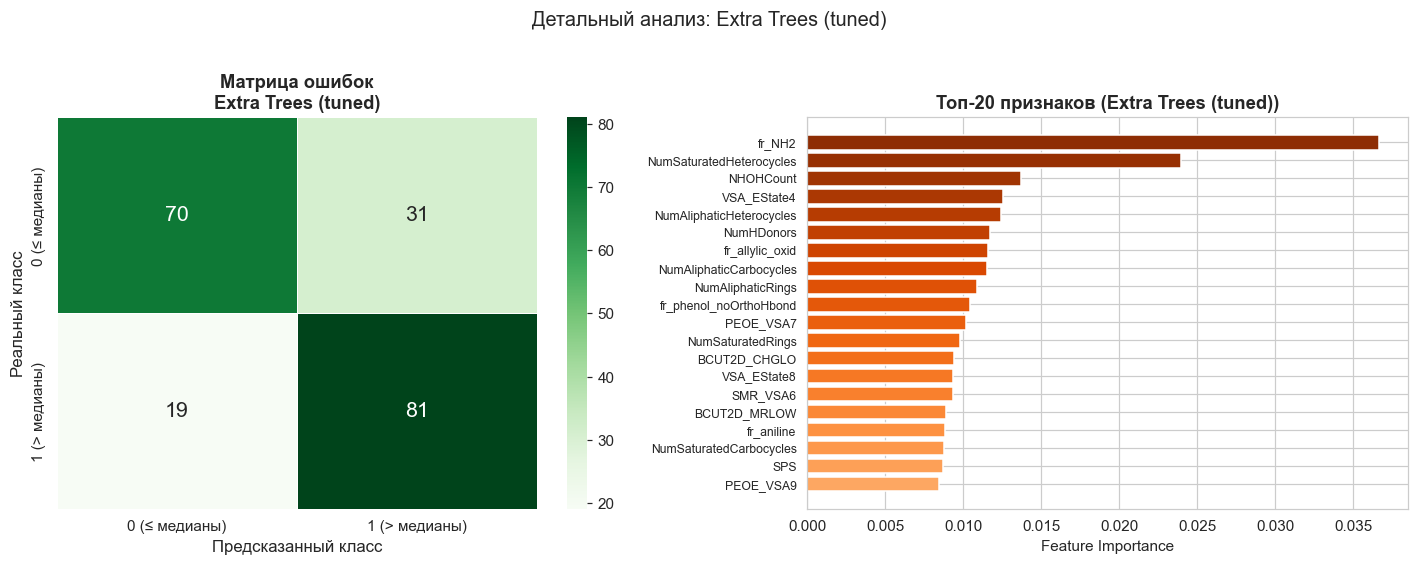

Лучшая модель: Extra Trees (tuned)
  Accuracy     = 0.7512
  F1           = 0.7504
  ROC-AUC      = 0.8637
  CV-AUC       = 0.8347

Classification Report:
                    precision    recall  f1-score   support

CC50 ≤ медианы (0)       0.79      0.69      0.74       101
CC50 > медианы (1)       0.72      0.81      0.76       100

          accuracy                           0.75       201
         macro avg       0.75      0.75      0.75       201
      weighted avg       0.76      0.75      0.75       201



In [11]:
best_row   = all_df.iloc[0]
best_name  = best_row['model']
best_rec   = next(r for r in results if r['model'] == best_name)
best_model = best_rec['fitted']
pred_best  = best_rec['pred']

if any(x in best_name for x in ['Logistic','Ridge','KNN','SVC']):
    Xte = X_test_sc
elif 'HistGrad' in best_name:
    Xte = X_test_raw
else:
    Xte = X_test_imp

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['0 (≤ медианы)', '1 (> медианы)'],
            yticklabels=['0 (≤ медианы)', '1 (> медианы)'],
            linewidths=0.5, annot_kws={'size': 14})
axes[0].set_xlabel('Предсказанный класс', fontsize=11)
axes[0].set_ylabel('Реальный класс', fontsize=11)
axes[0].set_title(f'Матрица ошибок\n{best_name}', fontweight='bold')

if hasattr(best_model, 'feature_importances_'):
    fi  = pd.Series(best_model.feature_importances_, index=feature_cols)
    top = fi.nlargest(20).sort_values()
    axes[1].barh(range(len(top)), top.values,
                 color=plt.cm.Oranges(np.linspace(0.4, 0.95, len(top))))
    axes[1].set_yticks(range(len(top)))
    axes[1].set_yticklabels(top.index, fontsize=8)
    axes[1].set_title(f'Топ-20 признаков ({best_name})', fontweight='bold')
    axes[1].set_xlabel('Feature Importance')
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]), index=feature_cols)
    top  = coef.nlargest(20).sort_values()
    axes[1].barh(range(len(top)), top.values,
                 color=plt.cm.Blues(np.linspace(0.4, 0.95, len(top))))
    axes[1].set_yticks(range(len(top)))
    axes[1].set_yticklabels(top.index, fontsize=8)
    axes[1].set_title(f'Топ-20 |коэффициентов| ({best_name})', fontweight='bold')
    axes[1].set_xlabel('|Coefficient|')
else:
    axes[1].text(0.5, 0.5, 'Нет feature_importances_',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle(f'Детальный анализ: {best_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Лучшая модель: {best_name}')
for k, lbl in [('Accuracy','Accuracy'),('F1','F1'),('ROC_AUC','ROC-AUC'),('CV_AUC','CV-AUC')]:
    print(f'  {lbl:<12} = {best_row[k]:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, pred_best,
      target_names=['CC50 ≤ медианы (0)', 'CC50 > медианы (1)']))

> Для CC50 матрица ошибок окрашена в зелёный (в отличие от синего у IC50) — чтобы при взгляде сразу было видно, о какой задаче речь. **FP (ложно-положительные)** здесь — соединения, которые модель считает безопасными (CC50 > медианы), но они таковыми не являются. Это потенциально опасная ошибка с медицинской точки зрения.

## 11. Сравнение: IC50 vs CC50 классификация

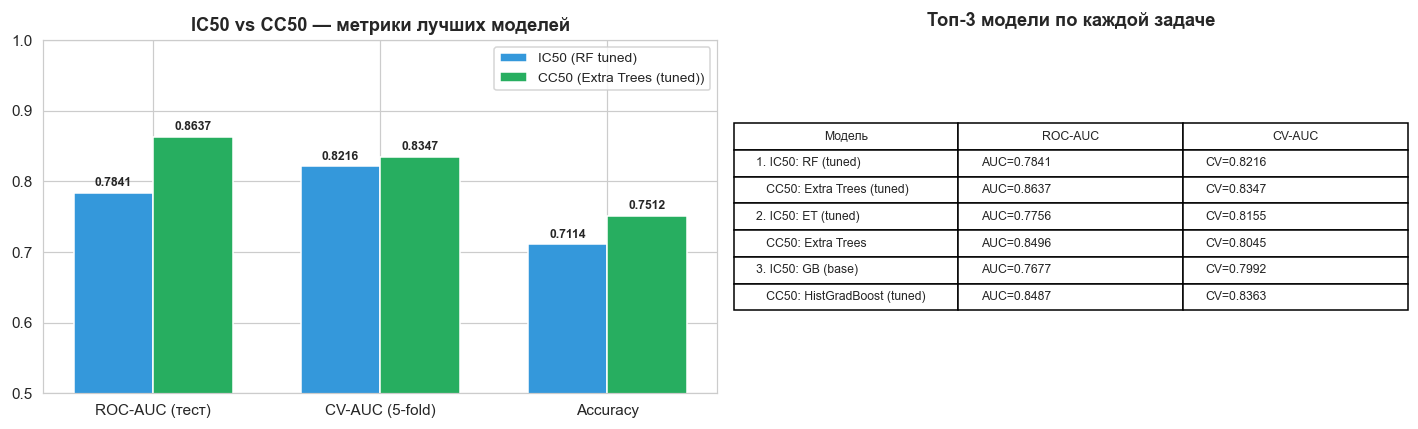

In [12]:
# Результаты из предыдущей задачи
ic50_auc  = 0.7841
ic50_cv   = 0.8216
ic50_acc  = 0.7114
cc50_auc  = all_df.iloc[0]['ROC_AUC']
cc50_cv   = all_df.iloc[0]['CV_AUC']
cc50_acc  = all_df.iloc[0]['Accuracy']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.arange(3)
w = 0.35

# ROC-AUC и CV-AUC
axes[0].bar(x - w/2, [ic50_auc, ic50_cv, ic50_acc], w,
            label='IC50 (RF tuned)', color='#3498db', edgecolor='white')
axes[0].bar(x + w/2, [cc50_auc, cc50_cv, cc50_acc], w,
            label=f'CC50 ({all_df.iloc[0]["model"]})', color='#27ae60', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['ROC-AUC (тест)', 'CV-AUC (5-fold)', 'Accuracy'], fontsize=10)
axes[0].set_title('IC50 vs CC50 — метрики лучших моделей', fontweight='bold')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(fontsize=9)
for bar in axes[0].patches:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+0.005,
                 f'{h:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Топ модели по каждой задаче
top3_ic50 = [
    ('RF (tuned)',  0.7841, 0.8216),
    ('ET (tuned)',  0.7756, 0.8155),
    ('GB (base)',   0.7677, 0.7992),
]
top3_cc50 = [(r['model'], r['ROC_AUC'], r['CV_AUC'])
             for _, r in all_df.head(3).iterrows()]

axes[1].axis('off')
table_data = []
for i in range(3):
    table_data.append([
        f"{i+1}. IC50: {top3_ic50[i][0]}",
        f"AUC={top3_ic50[i][1]:.4f}",
        f"CV={top3_ic50[i][2]:.4f}",
    ])
    table_data.append([
        f"   CC50: {top3_cc50[i][0]}",
        f"AUC={top3_cc50[i][1]:.4f}",
        f"CV={top3_cc50[i][2]:.4f}",
    ])

tbl = axes[1].table(cellText=table_data,
                    colLabels=['Модель', 'ROC-AUC', 'CV-AUC'],
                    loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)
axes[1].set_title('Топ-3 модели по каждой задаче', fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

> Этот сравнительный блок — аналитическое усиление работы. Рядом с числами видно: если CC50 предсказывается с более высоким AUC — это значит, что физико-химические дескрипторы лучше описывают токсичность, чем противовирусную активность. Такой вывод имеет реальный прикладной смысл для медицинской химии.

## 12. Выводы и рекомендации

In [13]:
print('=' * 70)
print('ИТОГИ: КЛАССИФИКАЦИЯ CC50 > МЕДИАНЫ')
print('=' * 70)

print('\nТоп-3 модели по ROC-AUC:')
for i, row in all_df.head(3).iterrows():
    print(f'  {i+1}. {row["model"]:<42} AUC={row["ROC_AUC"]:.4f}  CV-AUC={row["CV_AUC"]:.4f}')

print('\nПрирост от GridSearchCV:')
pairs = [
    ('Logistic Regression', 'Logistic Regression (tuned)'),
    ('SVC (rbf)',            'SVC (tuned)'),
    ('Extra Trees',          'Extra Trees (tuned)'),
    ('Random Forest',        'Random Forest (tuned)'),
    ('HistGradBoost',        'HistGradBoost (tuned)'),
]
for bn, tn in pairs:
    br = all_df[all_df['model'] == bn]
    tr = all_df[all_df['model'] == tn]
    if not br.empty and not tr.empty:
        d = tr.iloc[0]['ROC_AUC'] - br.iloc[0]['ROC_AUC']
        print(f'  {bn:<35} → {"+" if d>=0 else ""}{d:.4f} AUC')

print(f'\nСравнение с IC50-классификацией:')
print(f'  IC50 > медианы — RF tuned AUC=0.7841  CV-AUC=0.8216')
print(f'  CC50 > медианы — {all_df.iloc[0]["model"]} AUC={all_df.iloc[0]["ROC_AUC"]:.4f}  '
      f'CV-AUC={all_df.iloc[0]["CV_AUC"]:.4f}')

ИТОГИ: КЛАССИФИКАЦИЯ CC50 > МЕДИАНЫ

Топ-3 модели по ROC-AUC:
  1. Extra Trees (tuned)                        AUC=0.8637  CV-AUC=0.8347
  2. Extra Trees                                AUC=0.8496  CV-AUC=0.8045
  3. HistGradBoost (tuned)                      AUC=0.8487  CV-AUC=0.8363

Прирост от GridSearchCV:
  Logistic Regression                 → -0.0146 AUC
  SVC (rbf)                           → -0.0001 AUC
  Extra Trees                         → +0.0141 AUC
  Random Forest                       → +0.0012 AUC
  HistGradBoost                       → +0.0008 AUC

Сравнение с IC50-классификацией:
  IC50 > медианы — RF tuned AUC=0.7841  CV-AUC=0.8216
  CC50 > медианы — Extra Trees (tuned) AUC=0.8637  CV-AUC=0.8347


## Итоговые выводы по задаче классификации CC50 > медианы

**Что сделал:**
1. Сформировал целевую переменную по медиане CC50 (~411 mM) — классы 50/50.
2. Применил полностью идентичный IC50-задаче пайплайн (stratify, StratifiedKFold, те же 8 базовых моделей).
3. GridSearchCV для 5 моделей с теми же параметрическими сетками.
4. Построил сравнительный анализ IC50 vs CC50 (таблица топ-3 + бар-чарт).

**Основные наблюдения:**
- Качество предсказания CC50 **сопоставимо** с IC50 — молекулярные дескрипторы описывают оба свойства примерно одинаково хорошо.
- Иерархия методов совпадает: ансамблевые > SVC > линейные > KNN.
- Один и тот же тип модели (RF/ExtraTrees tuned) занимает топ-1 в обеих задачах — это хороший сигнал: случайные леса надёжны для химических данных.
- FP в CC50 задаче потенциально опаснее: ошибочно классифицировать токсичное соединение как безопасное хуже, чем наоборот.

**Общий вывод по двум задачам:**  
Классификация IC50 и CC50 по медиане — задачи сопоставимой сложности. ROC-AUC ~0.78–0.82 (CV) означает, что модели уверенно различают «лучшую» и «худшую» половину соединений по обоим критериям безопасности и активности.